# Coupled Cluster Doubles (CCD) for the Pairing Model

This notebook compares four methods for solving the pairing model:

1. **Exact Diagonalization** — ground truth via full diagonalization of the Hamiltonian
2. **MBPT2** — Many-Body Perturbation Theory to second order
3. **CCD** — Coupled Cluster Doubles
4. **UCCD** — Unitary Coupled Cluster Doubles with Trotterization

> **Note:** This is a corrected version using proper single-particle energies from the Fock matrix.

## Imports and Configuration

In [1]:
from functools import partial
import jax
import jax.numpy as jnp
import numpy as np
from jax import Array, jit
import matplotlib.pyplot as plt
from itertools import combinations
from scipy.linalg import eigh

jax.config.update("jax_enable_x64", True)

## 1. Exact Diagonalization

Exact diagonalization with corrected single-particle energies from the Fock matrix.

**Key fix:** Single-particle energies include the mean-field pairing contribution via the Fock matrix.

The system is parameterised by:
- `n_levels` — number of doubly degenerate single-particle levels (= `(hnum + pnum) // 2`)
- `n_pairs`  — number of fermion pairs occupying the reference state (= `hnum // 2`)

Both are derived automatically from `pnum` and `hnum`, so any even values work.

In [2]:
def exact_diagonalization_pairing(pnum, hnum, delta, g):
    """
    Exact diagonalization with CORRECTED single-particle energies.

    Works for any even pnum and hnum:
      - n_levels : total doubly-degenerate levels = (hnum + pnum) // 2
      - n_pairs  : pairs in the reference state   = hnum // 2

    Single-particle energies are taken from the Fock matrix, which
    includes the mean-field pairing contribution.
    """
    n_levels = (hnum + pnum) // 2   # total doubly-degenerate levels
    n_pairs  = hnum // 2            # pairs occupying hole levels

    # Basis: all ways to place n_pairs pairs in n_levels levels
    basis_states = list(combinations(range(n_levels), n_pairs))
    n_basis = len(basis_states)

    # Fock single-particle energies (matches init_pairing_fock)
    deltaval = 0.5 * delta
    gval     = -0.5 * g   # mean-field pairing contribution

    epsilon = np.zeros(n_levels)
    # Hole levels: indices 0 .. n_pairs-1  (level index l -> physical level 2*l)
    for l in range(n_pairs):
        epsilon[l] = deltaval * (2 * l) + gval
    # Particle levels: indices n_pairs .. n_levels-1
    for l in range(pnum // 2):
        epsilon[n_pairs + l] = deltaval * (hnum + 2 * l)

    # Construct Hamiltonian
    H = np.zeros((n_basis, n_basis))

    for i, state_i in enumerate(basis_states):
        for j, state_j in enumerate(basis_states):
            # Diagonal: sum of pair energies
            if i == j:
                H[i, j] = sum(2 * epsilon[k] for k in state_i)

            # Off-diagonal: pairing interaction
            for k in range(n_levels):
                for l in range(n_levels):
                    if l in state_j and k not in state_j:
                        state_temp = list(state_j)
                        state_temp.remove(l)
                        state_temp.append(k)
                        state_temp = tuple(sorted(state_temp))
                        if state_temp == state_i:
                            H[i, j] -= g / 2.0

    eigenvalues, eigenvectors = eigh(H)
    return eigenvalues, eigenvectors, basis_states, H

## 2. CCD Implementation

Implementation of Coupled Cluster Doubles (CCD), including:
- Initialization of the pairing interaction tensors
- Fock matrix construction
- T2 amplitude initialization via MBPT2
- CCD energy and iterative solver

In [3]:
def init_pairing_v(g, pnum, hnum):
    """Initialize pairing interaction tensors."""
    v_pppp = np.zeros((pnum, pnum, pnum, pnum))
    v_pphh = np.zeros((pnum, pnum, hnum, hnum))
    v_hhhh = np.zeros((hnum, hnum, hnum, hnum))
    gval = -0.5 * g
    p_even = np.arange(0, pnum, 2)
    h_even = np.arange(0, hnum, 2)
    
    for a in p_even:
        for b in p_even:
            v_pppp[a, a + 1, b, b + 1] = gval
            v_pppp[a + 1, a, b, b + 1] = -gval
            v_pppp[a, a + 1, b + 1, b] = -gval
            v_pppp[a + 1, a, b + 1, b] = gval
    
    for a in p_even:
        for i in h_even:
            v_pphh[a, a + 1, i, i + 1] = gval
            v_pphh[a + 1, a, i, i + 1] = -gval
            v_pphh[a, a + 1, i + 1, i] = -gval
            v_pphh[a + 1, a, i + 1, i] = gval
    
    for j in h_even:
        for i in h_even:
            v_hhhh[j, j + 1, i, i + 1] = gval
            v_hhhh[j + 1, j, i, i + 1] = -gval
            v_hhhh[j, j + 1, i + 1, i] = -gval
            v_hhhh[j + 1, j, i + 1, i] = gval
    
    v_pppp, v_pphh, v_hhhh = map(jnp.array, (v_pppp, v_pphh, v_hhhh))
    return v_pppp, v_pphh, v_hhhh

In [4]:
def init_pairing_fock(delta, g, pnum, hnum):
    """Initialize Fock matrix (includes mean-field pairing)."""
    deltaval = 0.5 * delta
    gval = -0.5 * g
    f_pp = np.zeros((pnum, pnum))
    f_hh = np.zeros((hnum, hnum))
    
    i_even = np.arange(0, hnum, 2)
    f_hh[i_even, i_even] = deltaval * i_even + gval
    f_hh[i_even + 1, i_even + 1] = deltaval * i_even + gval
    
    a_even = np.arange(0, pnum, 2)
    f_pp[a_even, a_even] = deltaval * (hnum + a_even)
    f_pp[a_even + 1, a_even + 1] = deltaval * (hnum + a_even)
    
    f_pp, f_hh = jnp.array(f_pp), jnp.array(f_hh)
    return f_pp, f_hh

In [5]:
def init_t2(v_pphh, f_pp, f_hh):
    """Initialize T2 amplitudes from MBPT2."""
    Fhh_diag = jnp.diag(f_hh)
    Fpp_diag = jnp.diag(f_pp)
    denom = (Fhh_diag[None, None, :, None] + Fhh_diag[None, None, None, :]
             - Fpp_diag[:, None, None, None] - Fpp_diag[None, :, None, None])
    return v_pphh / denom


@jit
def ccd_energy(v_pphh, t2):
    """Compute CCD correlation energy."""
    return 0.25 * jnp.sum(v_pphh * t2)


@jit
def ccd_iter(v_pppp, v_pphh, v_hhhh, f_pp, f_hh, t2):
    """One CCD iteration."""
    Hbar_pphh = (v_pphh + jnp.einsum("bc,acij->abij", f_pp, t2)
                 - jnp.einsum("ac,bcij->abij", f_pp, t2)
                 - jnp.einsum("abik,kj->abij", t2, f_hh)
                 + jnp.einsum("abjk,ki->abij", t2, f_hh)
                 + 0.5 * jnp.einsum("abcd,cdij->abij", v_pppp, t2)
                 + 0.5 * jnp.einsum("abkl,klij->abij", t2, v_hhhh))
    
    chi_hh = 0.5 * jnp.einsum("cdkl,cdjl->kj", v_pphh, t2)
    Hbar_pphh -= jnp.einsum("abik,kj->abij", t2, chi_hh) - jnp.einsum("abik,kj->abji", t2, chi_hh)
    
    chi_pp = -0.5 * jnp.einsum("cdkl,bdkl->cb", v_pphh, t2)
    Hbar_pphh += jnp.einsum("acij,cb->abij", t2, chi_pp) - jnp.einsum("acij,cb->baij", t2, chi_pp)
    
    chi_hhhh = 0.5 * jnp.einsum("cdkl,cdij->klij", v_pphh, t2)
    Hbar_pphh += 0.5 * jnp.einsum("abkl,klij->abij", t2, chi_hhhh)
    
    chi_phph = 0.5 * jnp.einsum("cdkl,dblj->bkcj", v_pphh, t2)
    Hbar_pphh += (jnp.einsum("bkcj,acik->abij", chi_phph, t2)
                  - jnp.einsum("bkcj,acik->baij", chi_phph, t2)
                  - jnp.einsum("bkcj,acik->abji", chi_phph, t2)
                  + jnp.einsum("bkcj,acik->baji", chi_phph, t2))
    
    Fhh_diag = jnp.diag(f_hh)
    Fpp_diag = jnp.diag(f_pp)
    denom = (Fhh_diag[None, None, :, None] + Fhh_diag[None, None, None, :]
             - Fpp_diag[:, None, None, None] - Fpp_diag[None, :, None, None])
    
    return t2 + Hbar_pphh / denom

In [6]:
def calculate_ccd_energy(pnum, hnum, delta, g, verbose=False):
    """Calculate CCD and MBPT2 energies."""
    v_pppp, v_pphh, v_hhhh = init_pairing_v(g, pnum, hnum)
    f_pp, f_hh = init_pairing_fock(delta, g, pnum, hnum)
    
    t2 = init_t2(v_pphh, f_pp, f_hh)
    mbpt2_erg = ccd_energy(v_pphh, t2)
    
    niter, mix, erg_old, eps = 200, 0.3, 0.0, jnp.float64(1.0e-10)
    
    for iter_count in range(niter):
        t2_new = ccd_iter(v_pppp, v_pphh, v_hhhh, f_pp, f_hh, t2)
        erg = ccd_energy(v_pphh, t2_new)
        if jnp.abs(erg - erg_old) / jnp.abs(erg) < eps:
            if verbose:
                print(f"CCD converged in {iter_count} iterations")
            break
        erg_old = erg
        t2 = mix * t2_new + (1.0 - mix) * t2
    
    if verbose:
        print(f"MBPT2 correlation: {mbpt2_erg:.10f}")
        print(f"CCD correlation:   {erg:.10f}")
    
    return float(erg), float(mbpt2_erg)

## 3. Unitary Coupled Cluster Doubles (UCCD) with Trotterization

UCCD uses the unitary ansatz:
$$|\psi\rangle = e^{T - T^\dagger} |\psi_\text{ref}\rangle$$
where $T - T^\dagger$ is anti-Hermitian (ensuring unitarity).

**Trotterization:**

The key idea is to *split* the full exponent over individual operator terms:
$$e^{\sum_k A_k} \approx \left[\prod_k e^{A_k/n}\right]^n$$
where $A_k = t_k(T_k - T_k^\dagger)$. With $n=1$ the non-commutativity of the $A_k$ introduces the largest splitting error; as $n \to \infty$ the product converges to the exact unitary. The Trotter time step is $dt = 1/n$.

**Bug in earlier version:** The previous code applied $\exp(T_\text{anti}\cdot dt)$ repeated $n$ times, which equals $\exp(T_\text{anti})$ for any $n$ — all Trotter counts gave the same answer. The fix is to exponentiate *each term separately*.

The amplitudes $\{t_k\}$ are optimized variationally.

In [7]:
def calculate_uccd_energy(pnum, hnum, delta, g, n_trotter=4, verbose=False):
    """
    Calculate UCCD energy with TRUE first-order Trotterization.

    The ansatz is |psi> = exp(sum_k t_k * A_k)|psi_ref>,  A_k = T_k - T_k†.

    True Trotterization splits over individual terms:
        exp(sum_k t_k*A_k)  ≈  [prod_k exp(t_k * A_k * dt)]^n,  dt = 1/n

    With n=1 the splitting (non-commutativity) error is largest; it vanishes
    as n → ∞.  The amplitudes {t_k} are optimized variationally.

    NOTE: the previous implementation applied exp(T_anti * dt) n times, which
    equals exp(T_anti) for any n, giving identical results for all Trotter
    counts.  This version exponentiates each operator term separately.
    """
    from scipy.linalg import expm
    from scipy.optimize import minimize

    n_levels = (hnum + pnum) // 2
    dt = 1.0 / n_trotter

    if verbose:
        print(f"  Trotter steps : {n_trotter}")
        print(f"  Trotter dt    : {dt:.6f}")

    eigenvalues, eigenvectors, basis_states, H_full = exact_diagonalization_pairing(
        pnum, hnum, delta, g)
    n_basis = len(basis_states)

    psi_ref = np.zeros(n_basis, dtype=complex)
    psi_ref[0] = 1.0

    # Build the list of individual anti-Hermitian operators A_k = T_k - T_k†
    anti_herm_ops = []
    for i in range(n_levels):
        for j in range(n_levels):
            if i == j:
                continue
            T_op = np.zeros((n_basis, n_basis), dtype=complex)
            for idx_bra, state_bra in enumerate(basis_states):
                for idx_ket, state_ket in enumerate(basis_states):
                    if j in state_ket and i not in state_ket:
                        state_new = tuple(sorted(
                            [x for x in state_ket if x != j] + [i]))
                        if state_new == state_bra:
                            T_op[idx_bra, idx_ket] = 1.0
            A_k = T_op - T_op.conj().T
            if np.any(np.abs(A_k) > 1e-10):
                anti_herm_ops.append(A_k)

    n_amplitudes = len(anti_herm_ops)
    if verbose:
        print(f"  Excitation operators: {n_amplitudes}")

    def uccd_energy_trotter(amplitudes):
        # Pre-compute exp(t_k * A_k * dt) for each individual operator
        step_ops = [expm(amplitudes[k] * anti_herm_ops[k] * dt)
                    for k in range(n_amplitudes)]
        psi = psi_ref.copy()
        for _ in range(n_trotter):      # repeat n_trotter times
            for U_k in step_ops:        # apply each factor in sequence
                psi = U_k @ psi
        psi /= np.linalg.norm(psi)
        return np.real(np.vdot(psi, H_full @ psi))

    initial_amps = np.random.uniform(-0.1, 0.1, n_amplitudes)
    result = minimize(
        uccd_energy_trotter, initial_amps,
        method='L-BFGS-B',
        bounds=[(-5, 5)] * n_amplitudes,
        options={'maxiter': 500, 'disp': False}
    )

    E_uccd_corr = result.fun - H_full[0, 0]

    if verbose:
        print(f"  Converged in {result.nit} iterations")
        print(f"  UCCD correlation energy: {E_uccd_corr:.10f}")

    return E_uccd_corr

## 4. Single Point Test at g = 0.5

Run all four methods at a single value of the pairing strength $g = 0.5$ to verify correctness and compare correlation energies.

In [8]:
# -----------------------------------------------------------------------
# System parameters — change these to explore different configurations.
#
#   hnum   : number of hole spin-orbitals  (= 2 * number of occupied pairs)
#   pnum   : number of particle spin-orbitals above the Fermi level
#   delta  : single-particle level spacing
#
# Requirements: hnum and pnum must both be even positive integers.
# The total number of doubly-degenerate levels is (hnum + pnum) // 2.
# -----------------------------------------------------------------------
hnum  = 4   # e.g. 4 -> 2 occupied pairs (4 fermions)
pnum  = 4   # e.g. 4 -> 2 unoccupied pairs above Fermi level
delta = 1.0
g_test = 0.5

assert hnum % 2 == 0 and hnum > 0, "hnum must be a positive even integer"
assert pnum % 2 == 0 and pnum > 0, "pnum must be a positive even integer"

n_pairs  = hnum // 2
n_levels = (hnum + pnum) // 2

print(f"Hole spin-orbitals   : {hnum}  ({n_pairs} occupied pairs)")
print(f"Particle spin-orbitals: {pnum}  ({pnum // 2} unoccupied pairs)")
print(f"Total doubly-degenerate levels: {n_levels}")
print(f"Basis dimension (exact diag)  : C({n_levels},{n_pairs}) = {__import__('math').comb(n_levels, n_pairs)}")
print(f"delta = {delta},  g_test = {g_test}")

Hole spin-orbitals   : 4  (2 occupied pairs)
Particle spin-orbitals: 4  (2 unoccupied pairs)
Total doubly-degenerate levels: 4
Basis dimension (exact diag)  : C(4,2) = 6
delta = 1.0,  g_test = 0.5


In [9]:
# Exact diagonalization
eigenvalues, eigenvectors, basis_states, H = exact_diagonalization_pairing(
    pnum, hnum, delta, g_test)

print(f"Basis dimension : {len(basis_states)}")
print(f"Basis states    : {basis_states}")
print(f"\nHamiltonian ({H.shape[0]}x{H.shape[1]}):")
print(H)
print("\nEigenvalues:")
for i, E in enumerate(eigenvalues):
    print(f"  E_{i}: {E:+.10f}")

E_exact = eigenvalues[0]
E_ref   = H[0, 0]

Basis dimension : 6
Basis states    : [(0, 1), (0, 2), (0, 3), (1, 2), (1, 3), (2, 3)]

Hamiltonian (6x6):
[[ 1.   -0.25 -0.25 -0.25 -0.25  0.  ]
 [-0.25  3.5  -0.25 -0.25  0.   -0.25]
 [-0.25 -0.25  5.5   0.   -0.25 -0.25]
 [-0.25 -0.25  0.    5.5  -0.25 -0.25]
 [-0.25  0.   -0.25 -0.25  7.5  -0.25]
 [ 0.   -0.25 -0.25 -0.25 -0.25 10.  ]]

Eigenvalues:
  E_0: +0.9298467604
  E_1: +3.4624686254
  E_2: +5.5000000000
  E_3: +5.5000000000
  E_4: +7.5525595084
  E_5: +10.0551251057


In [10]:
# CCD and MBPT2
E_ccd_corr, E_mbpt2_corr = calculate_ccd_energy(pnum, hnum, delta, g_test, verbose=True)

CCD converged in 74 iterations
MBPT2 correlation: -0.0623931624
CCD correlation:   -0.0833623353


In [11]:
# UCCD with different Trotter steps
trotter_steps = [1, 2, 4, 8]
uccd_results = {}

print("UCCD WITH DIFFERENT TROTTER STEPS")
print("=" * 50)
for n_trotter in trotter_steps:
    print(f"\n--- Trotter n={n_trotter}  (dt = {1.0/n_trotter:.6f}) ---")
    E_uccd_corr = calculate_uccd_energy(pnum, hnum, delta, g_test,
                                        n_trotter=n_trotter, verbose=True)
    uccd_results[n_trotter] = E_uccd_corr

UCCD WITH DIFFERENT TROTTER STEPS

--- Trotter n=1  (dt = 1.000000) ---
  Trotter steps : 1
  Trotter dt    : 1.000000
  Excitation operators: 12
  Converged in 7 iterations
  UCCD correlation energy: -0.0701506513

--- Trotter n=2  (dt = 0.500000) ---
  Trotter steps : 2
  Trotter dt    : 0.500000
  Excitation operators: 12
  Converged in 19 iterations
  UCCD correlation energy: -0.0701532395

--- Trotter n=4  (dt = 0.250000) ---
  Trotter steps : 4
  Trotter dt    : 0.250000
  Excitation operators: 12
  Converged in 7 iterations
  UCCD correlation energy: -0.0701481259

--- Trotter n=8  (dt = 0.125000) ---
  Trotter steps : 8
  Trotter dt    : 0.125000
  Excitation operators: 12
  Converged in 18 iterations
  UCCD correlation energy: -0.0701532396


In [12]:
# Comparison table
print(f"{'='*80}")
print("COMPARISON")
print(f"{'='*80}")
print(f"\n{'Method':24s} | {'dt':>8s} | {'Total E':>14s} | {'Corr E':>14s} | {'Error':>12s}")
print("-" * 80)
print(f"{'Exact':24s} | {'--':>8s} | {E_exact:+14.10f} | {E_exact - E_ref:+14.10f} | {'--':>12s}")
print(f"{'MBPT2':24s} | {'--':>8s} | {E_ref + E_mbpt2_corr:+14.10f} | {E_mbpt2_corr:+14.10f} | {abs(E_ref + E_mbpt2_corr - E_exact):12.2e}")
print(f"{'CCD':24s} | {'--':>8s} | {E_ref + E_ccd_corr:+14.10f} | {E_ccd_corr:+14.10f} | {abs(E_ref + E_ccd_corr - E_exact):12.2e}")

for n_trotter in trotter_steps:
    E_uccd = E_ref + uccd_results[n_trotter]
    label  = f"UCCD (n={n_trotter})"
    dt     = 1.0 / n_trotter
    print(f"{label:24s} | {dt:8.6f} | {E_uccd:+14.10f} | {uccd_results[n_trotter]:+14.10f} | {abs(E_uccd - E_exact):12.2e}")

COMPARISON

Method                   |       dt |        Total E |         Corr E |        Error
--------------------------------------------------------------------------------
Exact                    |       -- |  +0.9298467604 |  -0.0701532396 |           --
MBPT2                    |       -- |  +0.9376068376 |  -0.0623931624 |     7.76e-03
CCD                      |       -- |  +0.9166376647 |  -0.0833623353 |     1.32e-02
UCCD (n=1)               | 1.000000 |  +0.9298493487 |  -0.0701506513 |     2.59e-06
UCCD (n=2)               | 0.500000 |  +0.9298467605 |  -0.0701532395 |     9.93e-11
UCCD (n=4)               | 0.250000 |  +0.9298518741 |  -0.0701481259 |     5.11e-06
UCCD (n=8)               | 0.125000 |  +0.9298467604 |  -0.0701532396 |     1.11e-11


## 5. Energy Scan over Pairing Strength $g$

Compute ground state energies for all methods across a range of $g \in [-1, 1]$ and evaluate accuracy statistics.

In [13]:
g_values = np.linspace(-1, 1, 50)
energies_exact = np.zeros_like(g_values)
energies_ccd = np.zeros_like(g_values)
energies_mbpt2 = np.zeros_like(g_values)
energies_uccd = {nt: np.zeros_like(g_values) for nt in [1, 2, 4]}

print(f"Computing energies for {len(g_values)} values of g...")
for i, g in enumerate(g_values):
    evals, _, _, H_mat = exact_diagonalization_pairing(pnum, hnum, delta, g)
    energies_exact[i] = evals[0]
    E_ccd_c, E_mbpt2_c = calculate_ccd_energy(pnum, hnum, delta, g)
    E_ref = H_mat[0, 0]
    energies_ccd[i] = E_ref + E_ccd_c
    energies_mbpt2[i] = E_ref + E_mbpt2_c
    
    for nt in [1, 2, 4]:
        E_uccd_c = calculate_uccd_energy(pnum, hnum, delta, g, n_trotter=nt)
        energies_uccd[nt][i] = E_ref + E_uccd_c
    
    if (i + 1) % 10 == 0:
        print(f"  Progress: {i + 1}/{len(g_values)}")

print("Done!")

Computing energies for 50 values of g...
  Progress: 10/50
  Progress: 20/50
  Progress: 30/50
  Progress: 40/50
  Progress: 50/50
Done!


In [14]:
# Error statistics
error_ccd = np.abs(energies_ccd - energies_exact)
error_mbpt2 = np.abs(energies_mbpt2 - energies_exact)
error_uccd = {nt: np.abs(energies_uccd[nt] - energies_exact) for nt in [1, 2, 4]}

print(f"{'='*80}")
print("STATISTICS")
print(f"{'='*80}")
print(f"\n{'Method':25s} | {'Max Error':>15s} | {'Mean Error':>15s} | {'RMS Error':>15s}")
print("-" * 80)
print(f"{'MBPT2':25s} | {np.max(error_mbpt2):15.6e} | {np.mean(error_mbpt2):15.6e} | {np.sqrt(np.mean(error_mbpt2**2)):15.6e}")
print(f"{'CCD':25s} | {np.max(error_ccd):15.6e} | {np.mean(error_ccd):15.6e} | {np.sqrt(np.mean(error_ccd**2)):15.6e}")

for nt in [1, 2, 4]:
    label = f"UCCD (Trotter={nt})"
    print(f"{label:25s} | {np.max(error_uccd[nt]):15.6e} | {np.mean(error_uccd[nt]):15.6e} | {np.sqrt(np.mean(error_uccd[nt]**2)):15.6e}")

improvement_ccd = np.mean(error_mbpt2) / np.mean(error_ccd)
improvement_uccd = np.mean(error_mbpt2) / np.mean(error_uccd[4])
print(f"\nCCD is {improvement_ccd:.1f}x more accurate than MBPT2")
print(f"UCCD (Trotter=4) is {improvement_uccd:.1f}x more accurate than MBPT2")

STATISTICS

Method                    |       Max Error |      Mean Error |       RMS Error
--------------------------------------------------------------------------------
MBPT2                     |    1.654753e-01 |    2.604848e-02 |    4.554166e-02
CCD                       |    1.038781e-01 |    2.529166e-02 |    3.809835e-02
UCCD (Trotter=1)          |    1.136678e-05 |    6.714530e-07 |    2.100636e-06
UCCD (Trotter=2)          |    1.498135e-05 |    9.407891e-07 |    2.989035e-06
UCCD (Trotter=4)          |    2.375813e-05 |    1.249011e-06 |    4.254507e-06

CCD is 1.0x more accurate than MBPT2
UCCD (Trotter=4) is 20855.3x more accurate than MBPT2


## 6. Visualization

Eight-panel figure comparing all methods across the full scan range.

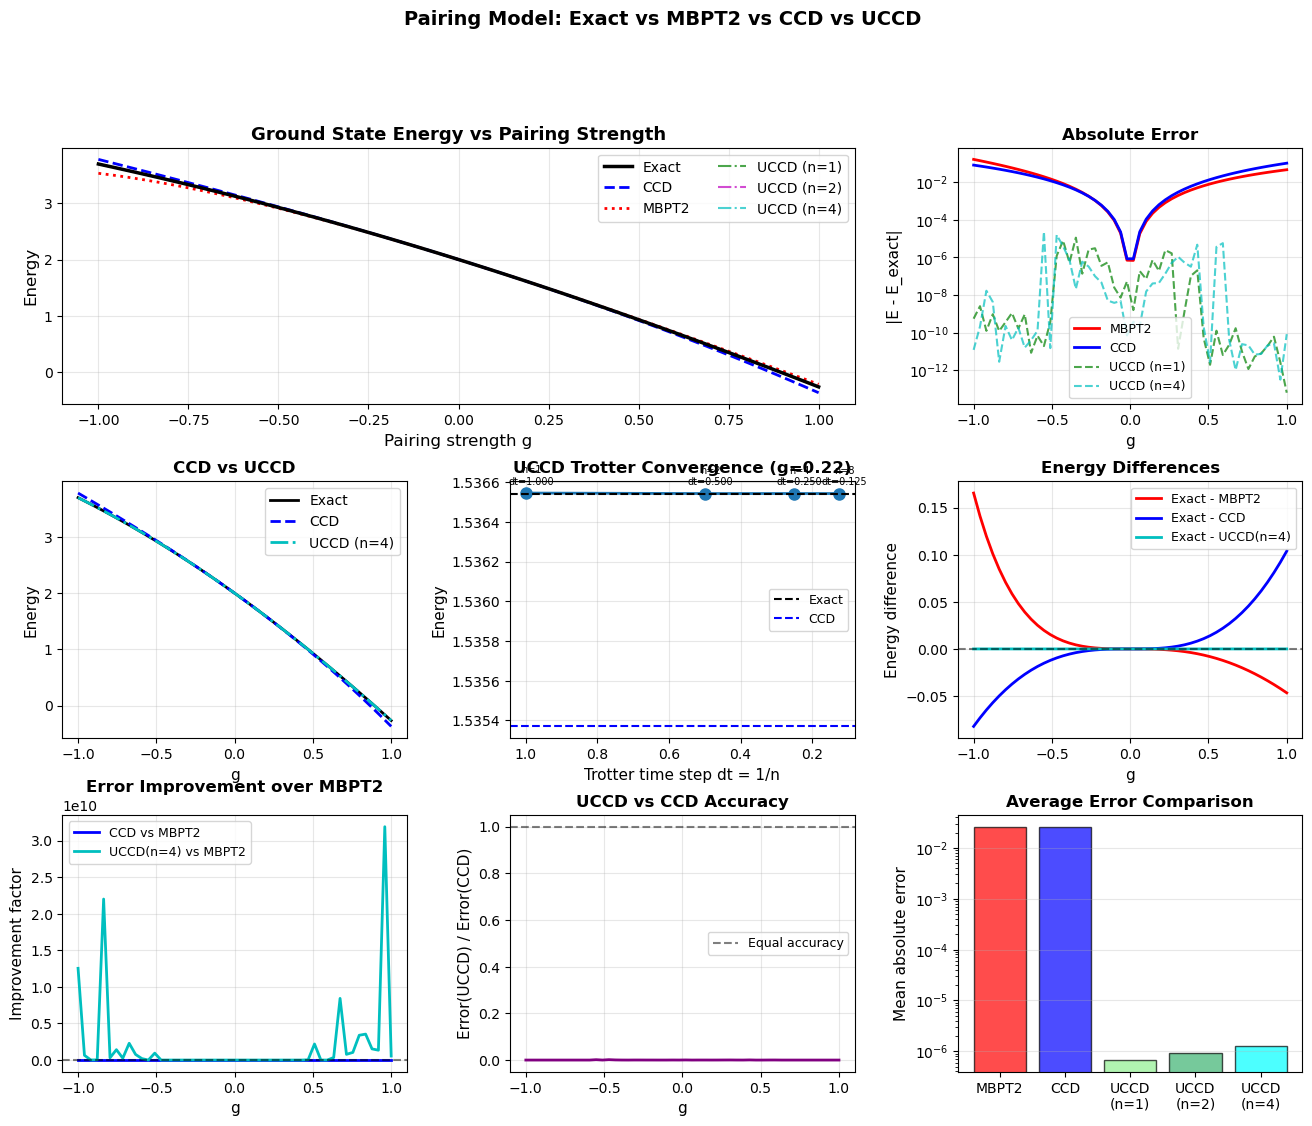

Plot saved: pairing_full_comparison.png


In [15]:
fig = plt.figure(figsize=(16, 12))
gs = fig.add_gridspec(3, 3, hspace=0.3, wspace=0.3)

# Plot 1: All energies
ax1 = fig.add_subplot(gs[0, :2])
ax1.plot(g_values, energies_exact, 'k-', lw=2.5, label='Exact', zorder=5)
ax1.plot(g_values, energies_ccd, 'b--', lw=2, label='CCD', zorder=4)
ax1.plot(g_values, energies_mbpt2, 'r:', lw=2, label='MBPT2', zorder=3)
ax1.plot(g_values, energies_uccd[1], 'g-.', lw=1.5, alpha=0.7, label='UCCD (n=1)', zorder=2)
ax1.plot(g_values, energies_uccd[2], 'm-.', lw=1.5, alpha=0.7, label='UCCD (n=2)', zorder=2)
ax1.plot(g_values, energies_uccd[4], 'c-.', lw=1.5, alpha=0.7, label='UCCD (n=4)', zorder=2)
ax1.set_xlabel('Pairing strength g', fontsize=12)
ax1.set_ylabel('Energy', fontsize=12)
ax1.set_title('Ground State Energy vs Pairing Strength', fontweight='bold', fontsize=13)
ax1.legend(fontsize=10, ncol=2)
ax1.grid(alpha=0.3)

# Plot 2: Errors (log scale)
ax2 = fig.add_subplot(gs[0, 2])
ax2.semilogy(g_values, error_mbpt2, 'r-', lw=2, label='MBPT2')
ax2.semilogy(g_values, error_ccd, 'b-', lw=2, label='CCD')
ax2.semilogy(g_values, error_uccd[1], 'g--', lw=1.5, alpha=0.7, label='UCCD (n=1)')
ax2.semilogy(g_values, error_uccd[4], 'c--', lw=1.5, alpha=0.7, label='UCCD (n=4)')
ax2.set_xlabel('g', fontsize=11)
ax2.set_ylabel('|E - E_exact|', fontsize=11)
ax2.set_title('Absolute Error', fontweight='bold', fontsize=12)
ax2.legend(fontsize=9)
ax2.grid(alpha=0.3, which='both')

# Plot 3: CCD vs UCCD comparison
ax3 = fig.add_subplot(gs[1, 0])
ax3.plot(g_values, energies_exact, 'k-', lw=2, label='Exact')
ax3.plot(g_values, energies_ccd, 'b--', lw=2, label='CCD')
ax3.plot(g_values, energies_uccd[4], 'c-.', lw=2, label='UCCD (n=4)')
ax3.set_xlabel('g', fontsize=11)
ax3.set_ylabel('Energy', fontsize=11)
ax3.set_title('CCD vs UCCD', fontweight='bold', fontsize=12)
ax3.legend(fontsize=10)
ax3.grid(alpha=0.3)

# Plot 4: UCCD convergence with Trotter steps
ax4 = fig.add_subplot(gs[1, 1])
g_idx = 30  # g ~= 0.2
trotter_range = [1, 2, 4, 8]
uccd_energies_at_g = []
for nt in trotter_range:
    if nt in energies_uccd:
        uccd_energies_at_g.append(energies_uccd[nt][g_idx])
    else:
        evals, _, _, H_mat = exact_diagonalization_pairing(pnum, hnum, delta, g_values[g_idx])
        E_ref_loc = H_mat[0, 0]
        E_uccd_c = calculate_uccd_energy(pnum, hnum, delta, g_values[g_idx], n_trotter=nt)
        uccd_energies_at_g.append(E_ref_loc + E_uccd_c)

dt_values = [1.0 / nt for nt in trotter_range]
ax4.plot(dt_values, uccd_energies_at_g, 'o-', lw=2, markersize=8)
ax4.axhline(energies_exact[g_idx], color='k', ls='--', lw=1.5, label='Exact')
ax4.axhline(energies_ccd[g_idx], color='b', ls='--', lw=1.5, label='CCD')
for nt, dt, E in zip(trotter_range, dt_values, uccd_energies_at_g):
    ax4.annotate(f'n={nt}\ndt={dt:.3f}', xy=(dt, E),
                 xytext=(4, 6), textcoords='offset points', fontsize=7, ha='center')
ax4.set_xlabel('Trotter time step dt = 1/n', fontsize=11)
ax4.set_ylabel('Energy', fontsize=11)
ax4.set_title(f'UCCD Trotter Convergence (g={g_values[g_idx]:.2f})', fontweight='bold', fontsize=12)
ax4.legend(fontsize=9)
ax4.grid(alpha=0.3)
ax4.invert_xaxis()  # smaller dt (more steps) on the right

# Plot 5: Energy differences
ax5 = fig.add_subplot(gs[1, 2])
ax5.plot(g_values, energies_exact - energies_mbpt2, 'r-', lw=2, label='Exact - MBPT2')
ax5.plot(g_values, energies_exact - energies_ccd, 'b-', lw=2, label='Exact - CCD')
ax5.plot(g_values, energies_exact - energies_uccd[4], 'c-', lw=2, label='Exact - UCCD(n=4)')
ax5.axhline(0, color='k', ls='--', alpha=0.5)
ax5.set_xlabel('g', fontsize=11)
ax5.set_ylabel('Energy difference', fontsize=11)
ax5.set_title('Energy Differences', fontweight='bold', fontsize=12)
ax5.legend(fontsize=9)
ax5.grid(alpha=0.3)

# Plot 6: Improvement factors
ax6 = fig.add_subplot(gs[2, 0])
improvement_ccd_vs_g = error_mbpt2 / (error_ccd + 1e-12)
improvement_uccd_vs_g = error_mbpt2 / (error_uccd[4] + 1e-12)
ax6.plot(g_values, improvement_ccd_vs_g, 'b-', lw=2, label='CCD vs MBPT2')
ax6.plot(g_values, improvement_uccd_vs_g, 'c-', lw=2, label='UCCD(n=4) vs MBPT2')
ax6.axhline(1, color='k', ls='--', alpha=0.5)
ax6.set_xlabel('g', fontsize=11)
ax6.set_ylabel('Improvement factor', fontsize=11)
ax6.set_title('Error Improvement over MBPT2', fontweight='bold', fontsize=12)
ax6.legend(fontsize=9)
ax6.grid(alpha=0.3)

# Plot 7: CCD vs UCCD error ratio
ax7 = fig.add_subplot(gs[2, 1])
ratio_uccd_ccd = error_uccd[4] / (error_ccd + 1e-12)
ax7.plot(g_values, ratio_uccd_ccd, 'purple', lw=2)
ax7.axhline(1, color='k', ls='--', alpha=0.5, label='Equal accuracy')
ax7.set_xlabel('g', fontsize=11)
ax7.set_ylabel('Error(UCCD) / Error(CCD)', fontsize=11)
ax7.set_title('UCCD vs CCD Accuracy', fontweight='bold', fontsize=12)
ax7.legend(fontsize=9)
ax7.grid(alpha=0.3)

# Plot 8: Bar chart - average error per method
ax8 = fig.add_subplot(gs[2, 2])
methods = ['MBPT2', 'CCD', 'UCCD\n(n=1)', 'UCCD\n(n=2)', 'UCCD\n(n=4)']
mean_errors = [
    np.mean(error_mbpt2),
    np.mean(error_ccd),
    np.mean(error_uccd[1]),
    np.mean(error_uccd[2]),
    np.mean(error_uccd[4])
]
colors = ['red', 'blue', 'lightgreen', 'mediumseagreen', 'cyan']
ax8.bar(methods, mean_errors, color=colors, alpha=0.7, edgecolor='black')
ax8.set_ylabel('Mean absolute error', fontsize=11)
ax8.set_title('Average Error Comparison', fontweight='bold', fontsize=12)
ax8.set_yscale('log')
ax8.grid(alpha=0.3, axis='y')

plt.suptitle('Pairing Model: Exact vs MBPT2 vs CCD vs UCCD',
             fontsize=14, fontweight='bold', y=0.995)
plt.savefig('pairing_full_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print("Plot saved: pairing_full_comparison.png")